#Menggunakan EfficientNetB0 di Dataset Baru

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -rf "/content/dataset"
!rsync -ah --info=progress2 "/content/drive/MyDrive/dataset/" "/content/dataset/"

        202.53M 100%   88.11kB/s    0:37:24 (xfr#7500, to-chk=0/7504)


In [ ]:
DATASET_PATH = "/content/dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
EPOCHS = 50

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import random
import shutil

import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

In [ ]:
dataset_dir = Path(DATASET_PATH)

class_counts = {}

for class_folder in dataset_dir.iterdir():
    if class_folder.is_dir():
        total_images = len(list(class_folder.glob("*")))
        class_counts[class_folder.name] = total_images

df_counts = pd.DataFrame(
    list(class_counts.items()),
    columns=["Kelas", "Jumlah"]
)

df_counts

,Kelas,Jumlah
0,Penuh,2500
1,Kosong,2500
2,Terisi,2500


In [ ]:
image_paths = []
labels = []

valid_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

for class_folder in dataset_dir.iterdir():
    if class_folder.is_dir():
        for img_path in class_folder.glob("*"):
            if img_path.suffix.lower() in valid_extensions:
                image_paths.append(str(img_path))
                labels.append(class_folder.name)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

df.head()

,image_path,label
0,/content/dataset/Penuh/Penuh_aug_0299.jpg,Penuh
1,/content/dataset/Penuh/Penuh_aug_0479.jpg,Penuh
2,/content/dataset/Penuh/Penuh_original_0143.jpg,Penuh
3,/content/dataset/Penuh/Penuh_aug_1917.jpg,Penuh
4,/content/dataset/Penuh/Penuh_aug_1856.jpg,Penuh


In [ ]:
print("Total gambar:", len(df))
print("Jumlah kelas:", df["label"].nunique())
print("Nama kelas:", sorted(df["label"].unique()))

Total gambar: 7500
Jumlah kelas: 3
Nama kelas: ['Kosong', 'Penuh', 'Terisi']


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 6000
Validation: 750
Test: 750


In [ ]:
print("Distribusi Train:")
display(train_df["label"].value_counts())

print("Distribusi Validation:")
display(val_df["label"].value_counts())

print("Distribusi Test:")
display(test_df["label"].value_counts())

Distribusi Train:


,count
label,
Terisi,2000
Kosong,2000
Penuh,2000


Distribusi Validation:


,count
label,
Penuh,250
Terisi,250
Kosong,250


Distribusi Test:


,count
label,
Penuh,250
Terisi,250
Kosong,250


In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 6000 validated image filenames belonging to 3 classes.
Found 750 validated image filenames belonging to 3 classes.
Found 750 validated image filenames belonging to 3 classes.


In [ ]:
class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print("Nama kelas:", class_names)
print("Jumlah kelas:", num_classes)

Nama kelas: ['Kosong', 'Penuh', 'Terisi']
Jumlah kelas: 3


In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 6,056,742 (23.10 MB)

 Trainable params: 2,007,171 (7.66 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_efficientnetb0_pure_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 975ms/step - accuracy: 0.8002 - loss: 0.4633
Epoch 1: val_accuracy improved from None to 0.96533, saving model to best_efficientnetb0_pure_cnn.keras

Epoch 1: finished saving model to best_efficientnetb0_pure_cnn.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 426s 1s/step - accuracy: 0.8782 - loss: 0.2910 - val_accuracy: 0.9653 - val_loss: 0.0914
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9538 - loss: 0.1257
Epoch 2: val_accuracy did not improve from 0.96533
375/375 ━━━━━━━━━━━━━━━━━━━━ 425s 1s/step - accuracy: 0.9572 - loss: 0.1152 - val_accuracy: 0.9627 - val_loss: 0.0749
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 980ms/step - accuracy: 0.9716 - loss: 0.0759
Epoch 3: val_accuracy improved from 0.96533 to 0.97067, saving model to best_efficientnetb0_pure_cnn.keras

Epoch 3: finished saving model to best_efficientnetb0_pure_cnn.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 419s 1s/step - accuracy: 0.9705 - loss: 0.0772 - val_accuracy: 0.9707 - 

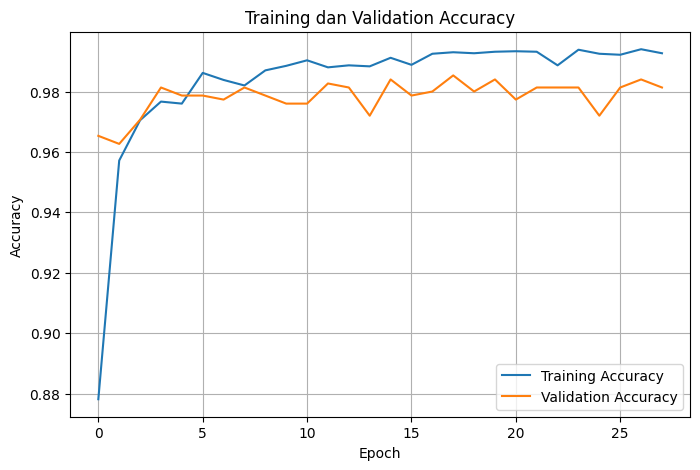

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training dan Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

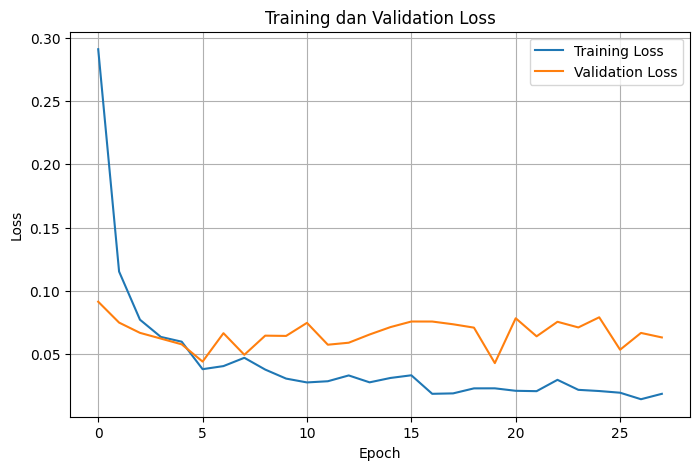

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training dan Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        print("Layer Conv2D terakhir:", layer.name)
        break

Layer Conv2D terakhir: top_conv


In [ ]:
import cv2
from tensorflow.keras.preprocessing import image

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
def display_gradcam(img_path, model, last_conv_layer_name, class_names, alpha=0.4):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)

    img_array_expanded = np.expand_dims(img_array, axis=0)
    img_array_preprocessed = preprocess_input(img_array_expanded)

    pred_prob = model.predict(img_array_preprocessed, verbose=0)
    pred_index = np.argmax(pred_prob[0])
    pred_label = class_names[pred_index]
    confidence = pred_prob[0][pred_index]

    heatmap = make_gradcam_heatmap(
        img_array_preprocessed,
        model,
        last_conv_layer_name,
        pred_index
    )

    heatmap = cv2.resize(heatmap, (IMG_SIZE[1], IMG_SIZE[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    original_img = image.img_to_array(img)
    original_img = np.uint8(original_img)

    superimposed_img = cv2.addWeighted(
        original_img,
        1 - alpha,
        heatmap_color,
        alpha,
        0
    )

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original_img.astype("uint8"))
    plt.title("Gambar Asli")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img.astype("uint8"))
    plt.title(f"Grad-CAM\nPrediksi: {pred_label} ({confidence:.2%})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Probabilitas tiap kelas:")
    for cls, prob in zip(class_names, pred_prob[0]):
        print(f"{cls}: {prob:.4f}")

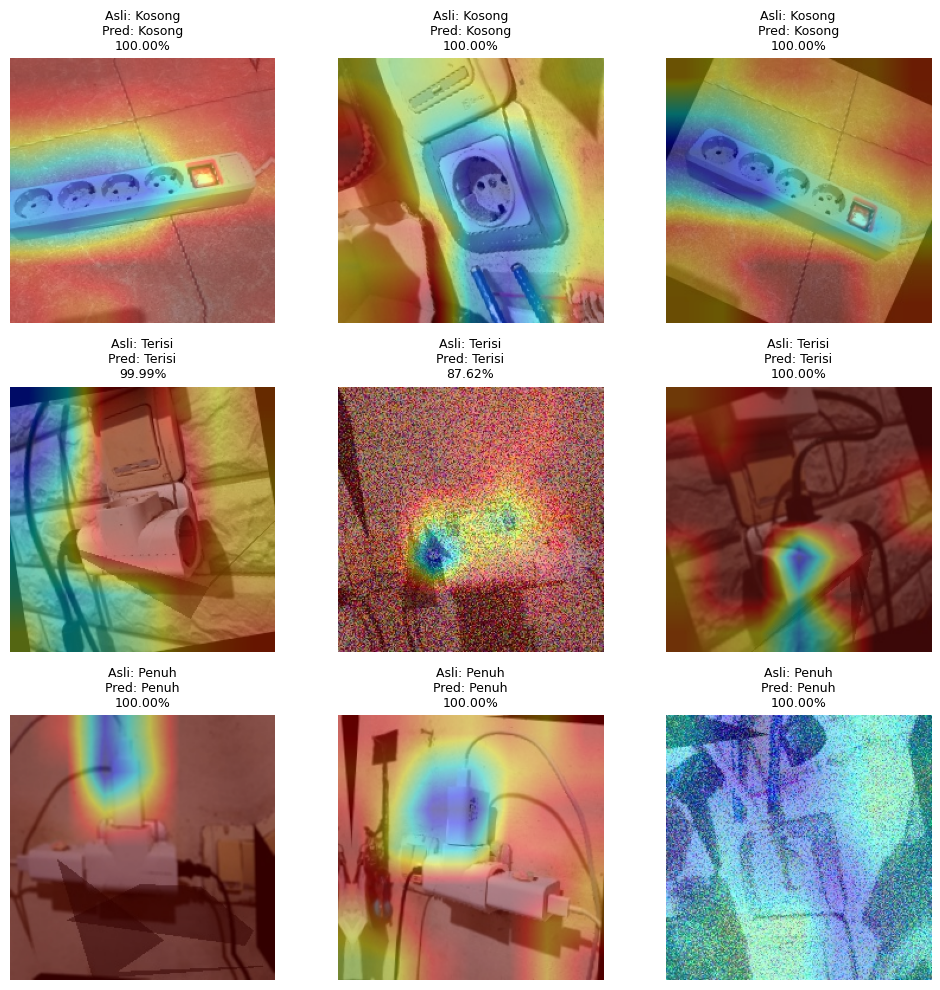

In [ ]:
def show_random_gradcam_3x3(test_df, desired_order=["Kosong", "Terisi", "Penuh"]):
    last_conv_layer_name = "top_conv"

    def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
        grad_model = tf.keras.models.Model(
            inputs=model.inputs,
            outputs=[model.get_layer(last_conv_layer_name).output, model.output]
        )

        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(img_array)

            if pred_index is None:
                pred_index = tf.argmax(predictions[0])

            class_channel = predictions[:, pred_index]

        grads = tape.gradient(class_channel, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]

        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0)

        if tf.reduce_max(heatmap) != 0:
            heatmap = heatmap / tf.reduce_max(heatmap)

        return heatmap.numpy()

    plt.figure(figsize=(10, 10))
    plot_index = 1

    for class_name in desired_order:
        class_data = test_df[test_df["label"] == class_name]

        if len(class_data) == 0:
            print(f"Kelas {class_name} tidak ditemukan di test_df")
            continue

        selected_data = class_data.sample(n=min(3, len(class_data)), random_state=None)

        for _, row in selected_data.iterrows():
            img_path = row["image_path"]
            true_label = row["label"]

            img = image.load_img(img_path, target_size=IMG_SIZE)
            img_array = image.img_to_array(img)

            img_batch = np.expand_dims(img_array, axis=0)
            img_batch = preprocess_input(img_batch)

            pred_prob = model.predict(img_batch, verbose=0)
            pred_index = np.argmax(pred_prob[0])
            pred_label = class_names[pred_index]
            confidence = pred_prob[0][pred_index]

            heatmap = make_gradcam_heatmap(
                img_batch,
                model,
                last_conv_layer_name,
                pred_index
            )

            heatmap = cv2.resize(heatmap, (IMG_SIZE[1], IMG_SIZE[0]))
            heatmap = np.uint8(255 * heatmap)
            heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

            original_img = np.uint8(img_array)

            gradcam_img = cv2.addWeighted(
                original_img,
                0.6,
                heatmap_color,
                0.4,
                0
            )

            plt.subplot(3, 3, plot_index)
            plt.imshow(gradcam_img)
            plt.axis("off")
            plt.title(
                f"Asli: {true_label}\nPred: {pred_label}\n{confidence:.2%}",
                fontsize=9
            )

            plot_index += 1

    plt.tight_layout()
    plt.show()


show_random_gradcam_3x3(test_df)

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.9733 - loss: 0.1879
Test Loss     : 0.1879
Test Accuracy : 0.9733


In [ ]:
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

47/47 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step


In [ ]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("===== Evaluasi EfficientNetB0 Pure CNN =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

===== Evaluasi EfficientNetB0 Pure CNN =====
Accuracy  : 0.9733
Precision : 0.9741
Recall    : 0.9733
F1-Score  : 0.9734


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      Kosong       0.99      0.98      0.98       250
       Penuh       0.99      0.96      0.97       250
      Terisi       0.94      0.99      0.96       250

    accuracy                           0.97       750
   macro avg       0.97      0.97      0.97       750
weighted avg       0.97      0.97      0.97       750



<Figure size 800x800 with 0 Axes>

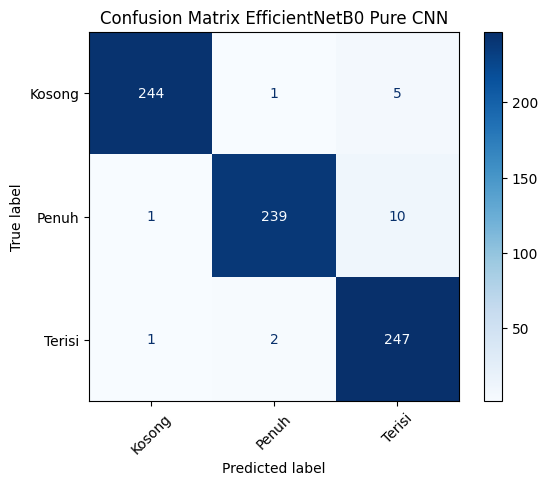

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix EfficientNetB0 Pure CNN")
plt.show()

In [ ]:
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]
test_acc = accuracy

gap_train_val = final_train_acc - final_val_acc
gap_train_test = final_train_acc - test_acc

print("===== Gap Accuracy =====")
print(f"Final Training Accuracy   : {final_train_acc:.4f}")
print(f"Final Validation Accuracy : {final_val_acc:.4f}")
print(f"Testing Accuracy          : {test_acc:.4f}")
print(f"Gap Train-Val             : {gap_train_val:.4f}")
print(f"Gap Train-Test            : {gap_train_test:.4f}")

===== Gap Accuracy =====
Final Training Accuracy   : 0.9927
Final Validation Accuracy : 0.9813
Testing Accuracy          : 0.9733
Gap Train-Val             : 0.0113
Gap Train-Test            : 0.0193


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/efficientnetb0_pure_cnn_model.keras"

model.save(SAVE_PATH)

print("Model berhasil disimpan di:")
print(SAVE_PATH)

Model berhasil disimpan di:
/content/drive/MyDrive/efficientnetb0_pure_cnn_model.keras


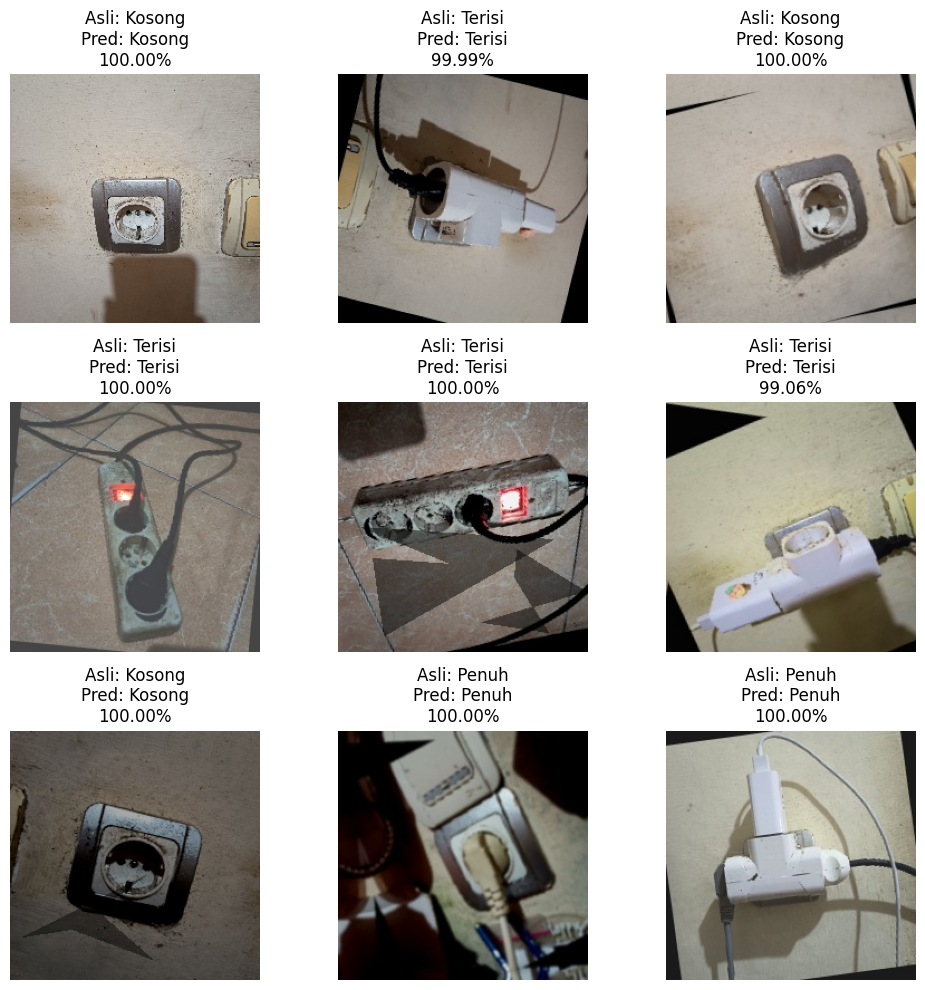

In [ ]:
sample_df = test_df.sample(9, random_state=SEED).reset_index(drop=True)

plt.figure(figsize=(10, 10))

for i in range(len(sample_df)):
    img_path = sample_df.loc[i, "image_path"]
    true_label = sample_df.loc[i, "label"]

    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array_expanded = np.expand_dims(img_array, axis=0)
    img_array_expanded = preprocess_input(img_array_expanded)

    pred_prob = model.predict(img_array_expanded, verbose=0)
    pred_index = np.argmax(pred_prob)
    pred_label = class_names[pred_index]
    confidence = pred_prob[0][pred_index]

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Asli: {true_label}\nPred: {pred_label}\n{confidence:.2%}")

plt.tight_layout()
plt.show()

In [ ]:
def show_feature_maps(img_path, model, layer_name="top_conv", img_size=(224, 224), max_features=16):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img)

    img_input = np.expand_dims(img_array, axis=0)
    img_input = preprocess_input(img_input)

    feature_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=model.get_layer(layer_name).output
    )

    feature_maps = feature_model.predict(img_input, verbose=0)
    feature_maps = feature_maps[0]

    total_features = min(max_features, feature_maps.shape[-1])

    plt.figure(figsize=(12, 12))

    for i in range(total_features):
        feature = feature_maps[:, :, i]

        plt.subplot(4, 4, i + 1)
        plt.imshow(feature, cmap="viridis")
        plt.title(f"Feature {i + 1}")
        plt.axis("off")

    plt.suptitle(f"Feature Map EfficientNetB0 - Layer: {layer_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

Label asli: Terisi
Path gambar: /content/dataset/Terisi/Terisi_aug_1602.jpg


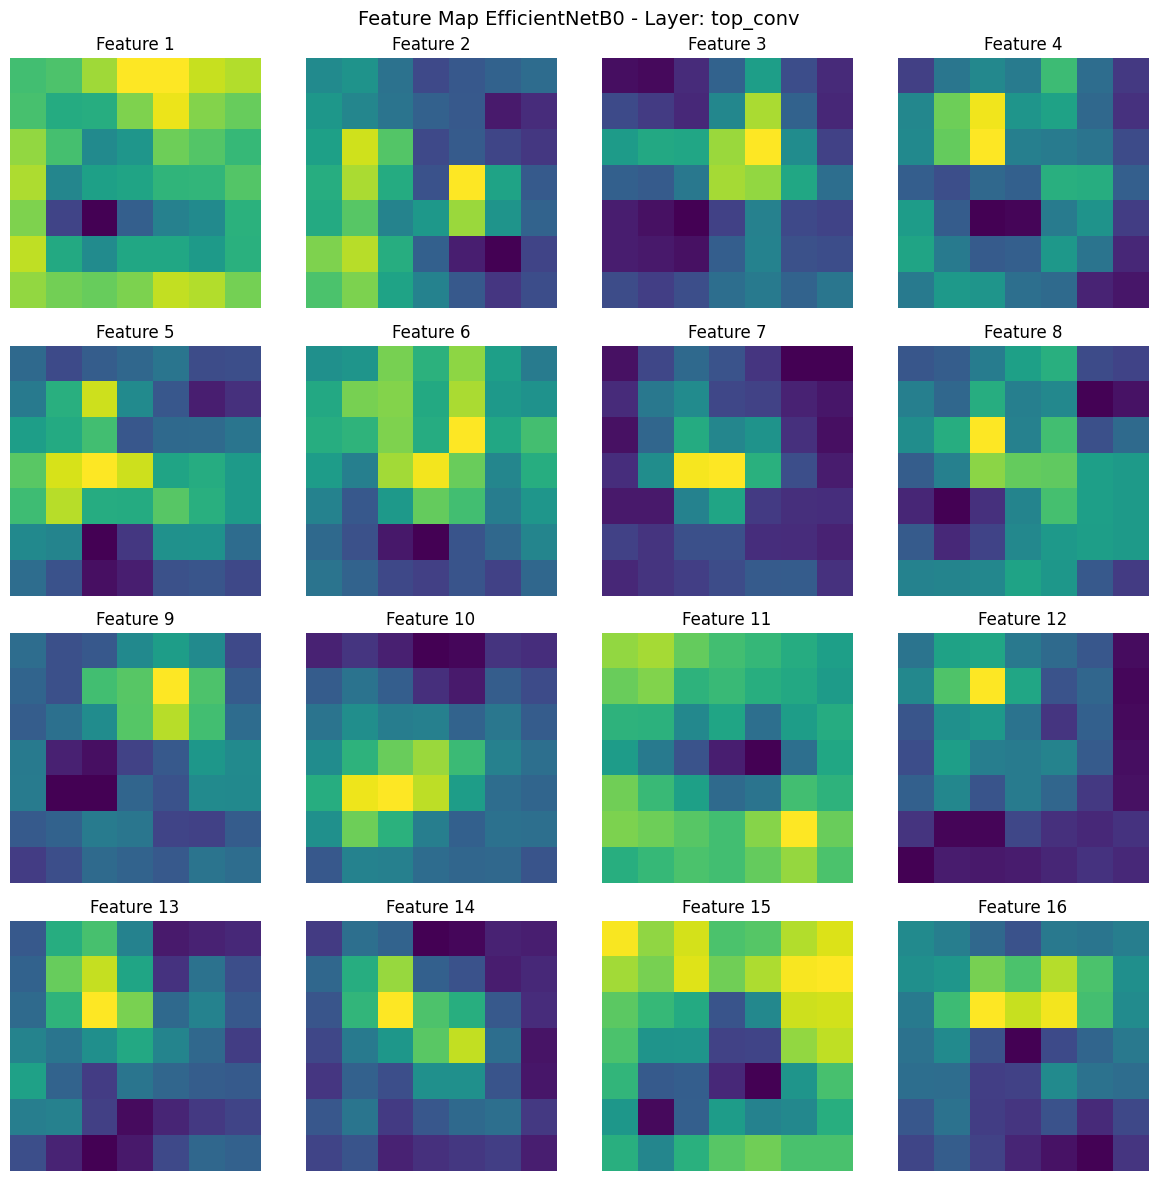

In [ ]:
best_model = tf.keras.models.load_model("best_efficientnetb0_pure_cnn.keras")
sample = test_df.sample(1).iloc[0]

img_path = sample["image_path"]
true_label = sample["label"]

print("Label asli:", true_label)
print("Path gambar:", img_path)

show_feature_maps(
    img_path=img_path,
    model=best_model,
    layer_name="top_conv",
    img_size=(224, 224),
    max_features=16
)